# EDA on the Titanic Dataset - CodeAlpha Data Analytics Internship

## Questions I want to answer
1. What does the dataset contain, and are there data quality problems?
2. Did gender affect survival?
3. Did passenger class affect survival?
4. Did age affect survival?
5. Did ticket price (fare) relate to survival?

In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")   # makes charts look cleaner

df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [45]:
print("Rows and columns:", df.shape)
df.info()

Rows and columns: (891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [46]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


How many rows and columns there are, which columns are numbers and which are text, and the average age and fare.

In [47]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

,0
deck,688
age,177
embarked,2
embark_town,2


In [48]:
# Same thing as a percentage
(df.isnull().mean() * 100).round(1).sort_values(ascending=False).head(5)

,0
deck,77.2
age,19.9
embarked,0.2
embark_town,0.2
sex,0.0


In [49]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 107


In [50]:
# 'deck' is mostly empty, so drop it
df = df.drop(columns=["deck"])

# Fill missing ages with the median (middle) age
df["age"] = df["age"].fillna(df["age"].median())

# Fill the few missing embark values with the most common one
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

df.isnull().sum().sum()   # should print 0

np.int64(0)

Deck was 77% missing, so it's unreliable.

2. Did gender affect survival?

sex
female    0.74
male      0.19
Name: survived, dtype: float64


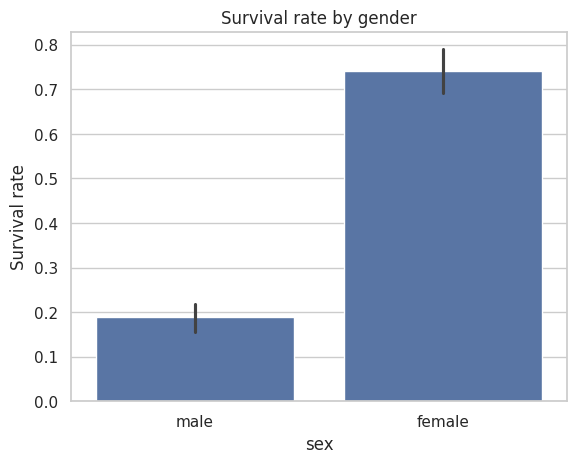

In [51]:
print(df.groupby("sex")["survived"].mean().round(2))

sns.barplot(x="sex", y="survived", data=df)
plt.title("Survival rate by gender")
plt.ylabel("Survival rate")
plt.show()

3. Did class matter?

pclass
1    0.63
2    0.47
3    0.24
Name: survived, dtype: float64


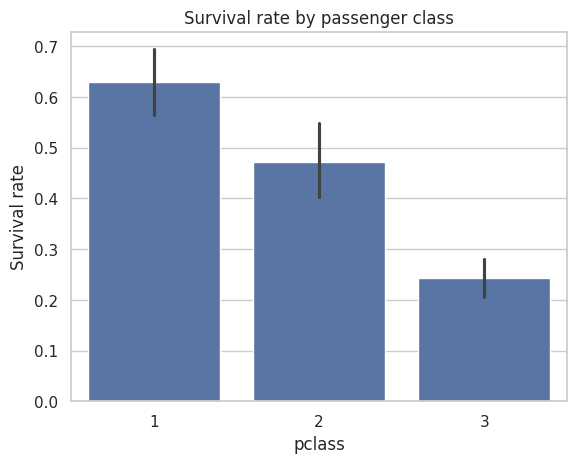

In [52]:
print(df.groupby("pclass")["survived"].mean().round(2))

sns.barplot(x="pclass", y="survived", data=df)
plt.title("Survival rate by passenger class")
plt.ylabel("Survival rate")
plt.show()

4. Did age matter?

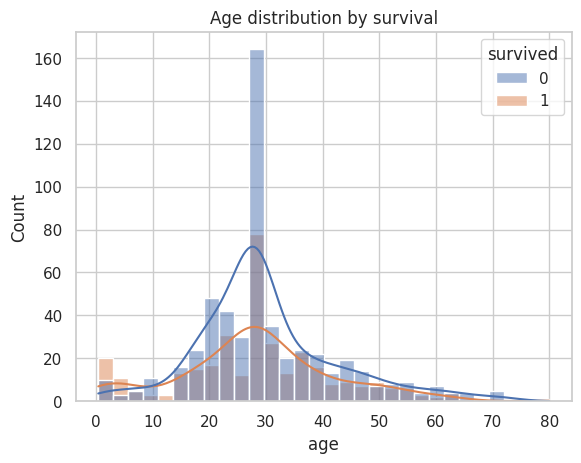

In [53]:
sns.histplot(data=df, x="age", hue="survived", bins=30, kde=True)
plt.title("Age distribution by survival")
plt.show()

Detecting anomalies (outliers):

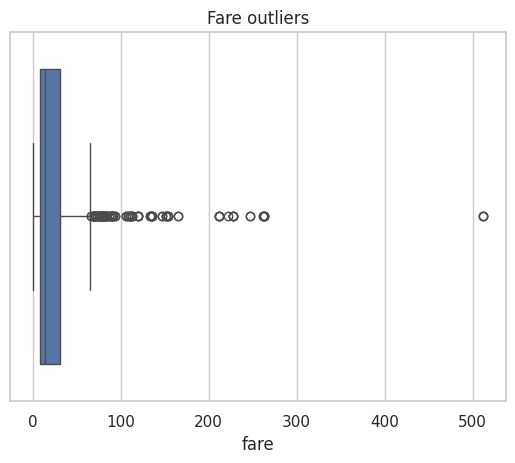

In [54]:
sns.boxplot(x=df["fare"])
plt.title("Fare outliers")
plt.show()

## Hypothesis Test 1
H0: Gender and survival are independent.

H1: Gender and survival are related.

In [55]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["sex"], df["survived"])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
print("p-value:", p)

if p < 0.05:
    print("Reject H0: gender and survival ARE related.")
else:
    print("Fail to reject H0: no significant relationship found.")

survived    0    1
sex               
female     81  233
male      468  109
p-value: 1.1973570627755645e-58
Reject H0: gender and survival ARE related.


## Hypothesis Test 2
H0: Survivors and non-survivors paid the same average fare.

H1: The average fares are different.

In [56]:
from scipy.stats import ttest_ind

survived_fare = df[df["survived"] == 1]["fare"]
died_fare = df[df["survived"] == 0]["fare"]

print("Average fare (survived):", round(survived_fare.mean(), 2))
print("Average fare (died):", round(died_fare.mean(), 2))

t_stat, p = ttest_ind(survived_fare, died_fare, equal_var=False)
print("p-value:", p)

Average fare (survived): 48.4
Average fare (died): 22.12
p-value: 2.6993323503141236e-11


The p-value was far below 0.05, so I reject the null hypothesis. Gender is significantly related to survival.

Correlation heatmap

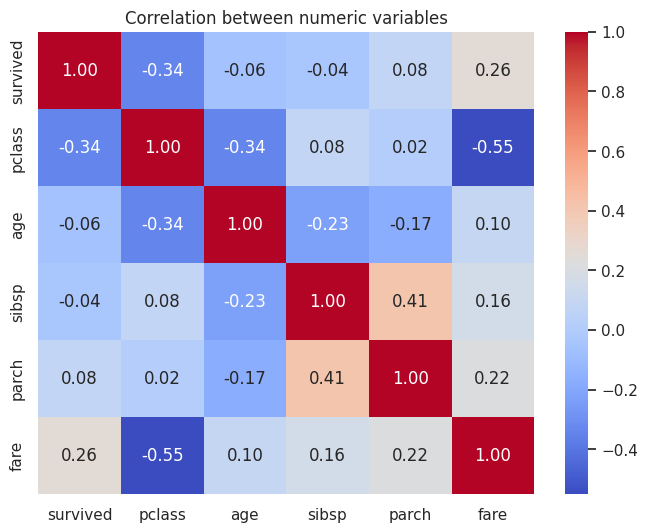

In [57]:
num_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between numeric variables")
plt.show()

Values near +1 or -1 mean a strong relationship; near 0 means little or none. Notice that pclass and survived have a negative correlation. Lower class number (1st class) means higher survival.

## Conclusions
1. Data quality: deck was ~77% missing and was dropped; age (~20% missing)
   was filled with the median.
2. Gender: women survived at ~74% vs men at ~19%. The chi-square test
   confirmed this is statistically significant (p < 0.05).
3. Class: survival fell from 1st class to 3rd class.
4. Age: [write what your histogram showed].
5. Fare: [write what your t-test and boxplot showed, including outliers].

## Limitations
Filling missing ages with the median is a simplification. Correlation
does not prove causation.